# Homework 02: Multi-Class Classification with Neural Networks

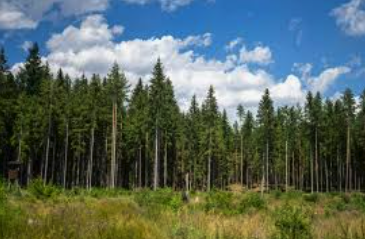

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [3]:
%pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0=all, 1=filter INFO, 2=filter INFO+WARNING, 3=errors only


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

$$k\cdot\sigma$$

In [5]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [7]:
# Your code here
# Problem 1 — Part A: Stratified train/test split + standardization
# In this step I’m creating a **stratified** train/test split so each class keeps the same proportions in both sets. 
# Then I standardize the features using `StandardScaler`, making sure I **fit only on the training set** (to avoid data leakage) and 
# Then transform both train and test. This matters because neural nets train more smoothly when inputs are on a comparable scale, and it keeps my evaluation honest.

# Part A: Stratified train/test split and standardization

# --- 1) Stratified split (preserve class proportions) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_sub,
    y_sub,
    test_size=0.2,
    random_state=random_seed,
    stratify=y_sub
)

# Quick sanity checks on shapes + class balance
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape,  "y_test  shape:", y_test.shape)
print("Train class counts:", Counter(y_train))
print("Test  class counts:", Counter(y_test))

# --- 2) Standardize features (fit scaler ONLY on training data to avoid leakage) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validation: training data should be ~mean 0, std 1 (per-feature); test will be close-ish
print("\nScaled feature check (training set):")
print("Mean (first 5 features):", np.mean(X_train_scaled, axis=0)[:5])
print("Std  (first 5 features):", np.std(X_train_scaled, axis=0)[:5])

# Extra safety check: make sure labels look like 0..6 and match model expectation
unique_labels = np.unique(y_train)
print("\nUnique labels in y_train:", unique_labels)
assert unique_labels.min() == 0 and unique_labels.max() == 6, "Expected labels to be in {0..6}."


X_train shape: (15383, 54) y_train shape: (15383,)
X_test  shape: (3846, 54) y_test  shape: (3846,)
Train class counts: Counter({np.int32(5): 2198, np.int32(1): 2198, np.int32(0): 2198, np.int32(2): 2198, np.int32(6): 2197, np.int32(3): 2197, np.int32(4): 2197})
Test  class counts: Counter({np.int32(3): 550, np.int32(4): 550, np.int32(6): 550, np.int32(1): 549, np.int32(0): 549, np.int32(5): 549, np.int32(2): 549})

Scaled feature check (training set):
Mean (first 5 features): [-4.39773320e-16 -5.36899340e-17 -4.39960967e-17  8.00099620e-17
  2.54659165e-17]
Std  (first 5 features): [1. 1. 1. 1. 1.]

Unique labels in y_train: [0 1 2 3 4 5 6]


### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



n_features: 54 | n_classes: 7


2026-02-03 17:45:25.248705: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3745 - loss: 1.7356 - val_accuracy: 0.4950 - val_loss: 1.5043
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5362 - loss: 1.3337 - val_accuracy: 0.5596 - val_loss: 1.1940
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5887 - loss: 1.0961 - val_accuracy: 0.5941 - val_loss: 1.0344
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6143 - loss: 0.9763 - val_accuracy: 0.6071 - val_loss: 0.9537
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6259 - loss: 0.9119 - val_accuracy: 0.6204 - val_loss: 0.9074
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6373 - loss: 0.8720 - val_accuracy: 0.6321 - val_loss: 0.8765
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6478 - loss: 0.8435 - val_accuracy: 0.6415 - val_loss: 0.8531
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6586 - loss: 0.8210 - val_accurac

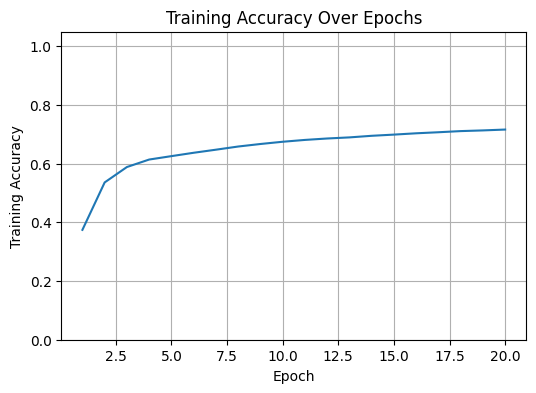

In [8]:
# Your code here
## Problem 1 — Part B: Build, compile, train, and evaluate the baseline network
# In this part I build the baseline neural network exactly as specified (64 → 32 → output), compile it with Adam using the given learning rate, train it for 20 epochs, and 
# then evaluate it on both train and test to sanity-check overfitting. I also add one simple accuracy plot at the end so I can visually confirm the training behavior matches the printed results.

# Problem 1 — Part B: Build, compile, train, evaluate, and add a simple visual

# --- 0) Quick safety checks so I don't get weird errors later ---
# I’m making sure Part A already ran and created the scaled arrays.
required_vars = ["X_train_scaled", "X_test_scaled", "y_train", "y_test"]
missing = [v for v in required_vars if v not in globals()]
assert not missing, f"Missing variables (run Part A first): {missing}"

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))
print("n_features:", n_features, "| n_classes:", n_classes)

# --- 1) Build the model (input -> 64 -> 32 -> output) ---
model = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(n_classes, activation="softmax")
])

print(model.summary())

# --- 2) Compile the model (per instructions) ---
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- 3) Train the model (20 epochs, batch size 32) ---
# I’m using a validation split from the training set so I can spot overfitting early.
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- 4) Evaluate on train and test (sanity check generalization) ---
train_loss, train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nFinal Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Final Test  Accuracy: {test_acc:.4f} | Test  Loss: {test_loss:.4f}")

# --- 5) Simple visual: training accuracy over epochs (goes AFTER history exists) ---
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [9]:
# Set a1a to the final training accuracy at epoch 20
# I’m pulling this directly from the training History object so I’m not copying numbers by hand.
# (This also makes it reproducible if I rerun training.)

a1a = float(history.history["accuracy"][-1])
print(f"Pulled a1a from history (epoch 20 train accuracy): {a1a:.4f}")

Pulled a1a from history (epoch 20 train accuracy): 0.7165


In [10]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7165


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


Training with batch_size = 4
Epoch 1/20


3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5038 - loss: 1.3592 - val_accuracy: 0.6120 - val_loss: 0.9964
Epoch 2/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6380 - loss: 0.9009 - val_accuracy: 0.6571 - val_loss: 0.8592
Epoch 3/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6734 - loss: 0.8157 - val_accuracy: 0.6747 - val_loss: 0.8051
Epoch 4/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6932 - loss: 0.7709 - val_accuracy: 0.6883 - val_loss: 0.7677
Epoch 5/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7026 - loss: 0.7389 - val_accuracy: 0.6987 - val_loss: 0.7394
Epoch 6/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7105 - loss: 0.7137 - val_accuracy: 0.7043 - val_loss: 0.7164
Epoch 7/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7205 - loss: 0.6926 - val_accuracy: 0.7117 - val_loss: 0.6977
Epoch 8/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7276 - loss: 0.6749 - val_accurac

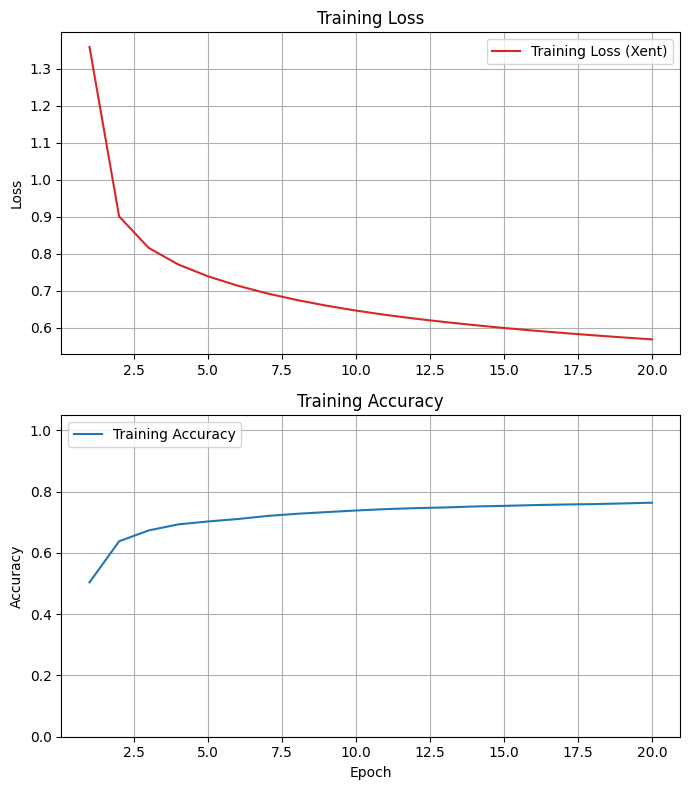

Final Training Loss:     0.5683
Final Training Accuracy: 0.7639
Final training accuracy at epoch 20 (batch_size=4): 0.7639

Training with batch_size = 8
Epoch 1/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4255 - loss: 1.5631 - val_accuracy: 0.5674 - val_loss: 1.1958
Epoch 2/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5991 - loss: 1.0367 - val_accuracy: 0.6064 - val_loss: 0.9525
Epoch 3/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6385 - loss: 0.8926 - val_accuracy: 0.6490 - val_loss: 0.8740
Epoch 4/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6669 - loss: 0.8324 - val_accuracy: 0.6685 - val_loss: 0.8315
Epoch 5/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6808 - loss: 0.7959 - val_accuracy: 0.6776 - val_loss: 0.8025
Epoch 6/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6915 - loss: 0.7692 - val_accuracy: 0.6844 - val_loss: 0.7798
Epoch 7/20
1539/1539 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0

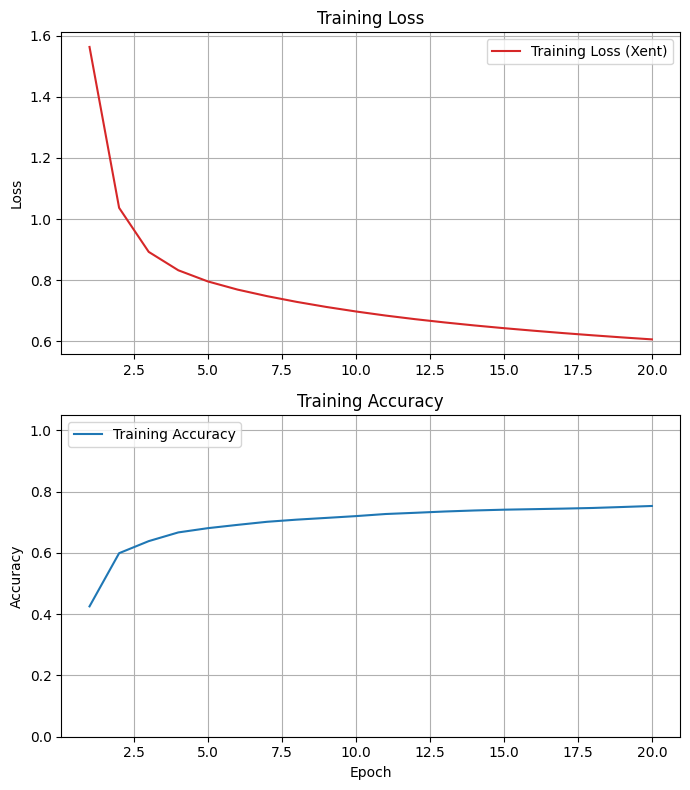

Final Training Loss:     0.6063
Final Training Accuracy: 0.7532
Final training accuracy at epoch 20 (batch_size=8): 0.7532

Training with batch_size = 16
Epoch 1/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3933 - loss: 1.7004 - val_accuracy: 0.4989 - val_loss: 1.3924
Epoch 2/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5596 - loss: 1.1952 - val_accuracy: 0.6035 - val_loss: 1.0608
Epoch 3/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6240 - loss: 0.9737 - val_accuracy: 0.6318 - val_loss: 0.9337
Epoch 4/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6491 - loss: 0.8843 - val_accuracy: 0.6578 - val_loss: 0.8734
Epoch 5/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6659 - loss: 0.8358 - val_accuracy: 0.6737 - val_loss: 0.8354
Epoch 6/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6751 - loss: 0.8033 - val_accuracy: 0.6825 - val_loss: 0.8079
Epoch 7/20
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6840 - loss:

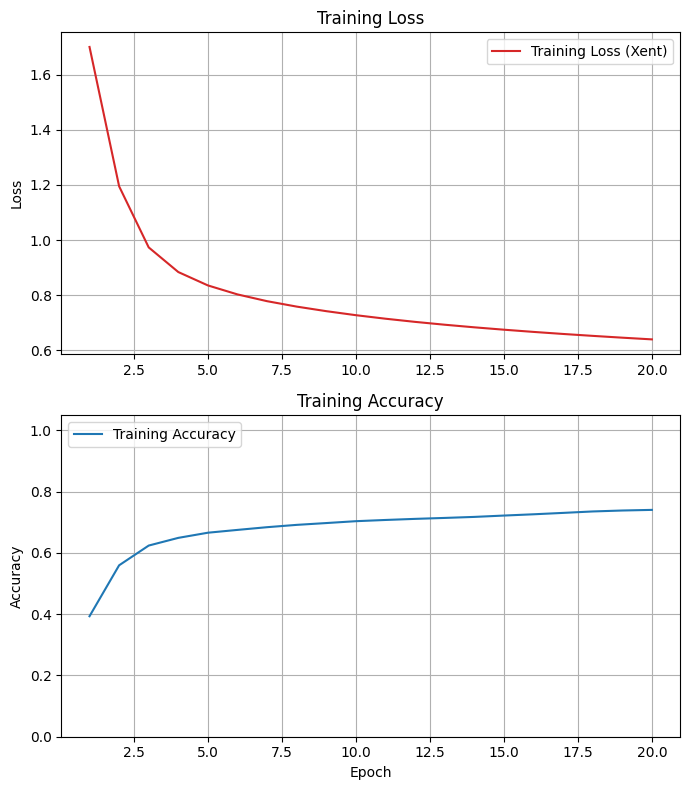

Final Training Loss:     0.6403
Final Training Accuracy: 0.7405
Final training accuracy at epoch 20 (batch_size=16): 0.7405

Training with batch_size = 128
Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1758 - loss: 1.9716 - val_accuracy: 0.2265 - val_loss: 1.8569
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3168 - loss: 1.7573 - val_accuracy: 0.3864 - val_loss: 1.6689
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4532 - loss: 1.5788 - val_accuracy: 0.4992 - val_loss: 1.5045
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5232 - loss: 1.4216 - val_accuracy: 0.5437 - val_loss: 1.3607
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5603 - loss: 1.2866 - val_accuracy: 0.5713 - val_loss: 1.2430
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5788 - loss: 1.1802 - val_accuracy: 0.5889 - val_loss: 1.1540
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5960 - loss: 1.1005 - va

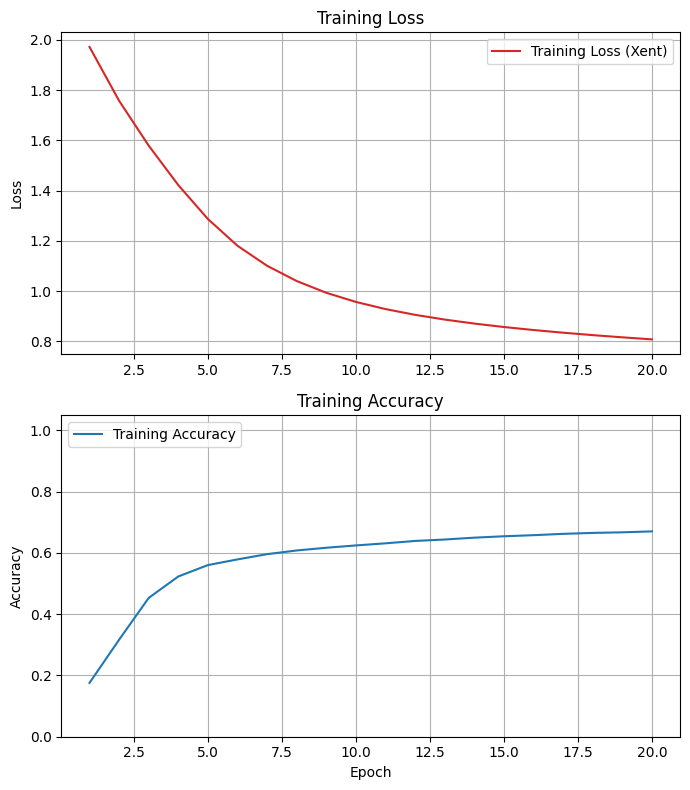

Final Training Loss:     0.8076
Final Training Accuracy: 0.6702
Final training accuracy at epoch 20 (batch_size=128): 0.6702

Summary: Final Training Accuracy at Epoch 20
batch_size=  4 -> acc=0.7639
batch_size=  8 -> acc=0.7532
batch_size= 16 -> acc=0.7405
batch_size=128 -> acc=0.6702

Best batch size (by epoch-20 training accuracy): 4
Best accuracy found (epoch 20): 0.7639


In [11]:
# Your code here
## Problem 2 — Batch Sizes (4, 8, 16, 128)

# In this section I’m keeping the model architecture and optimizer settings the same as the baseline, and I’m only changing the **batch size**. 
# This matters because batch size changes how noisy the gradient updates are: smaller batches usually learn with noisier updates (sometimes better generalization), while larger batches are smoother but can converge differently. 
# I’ll run four experiments, plot each training run using `plot_history`, and then pick the batch size that produces the **best accuracy at epoch 20**.

# Runs 4 experiments with batch sizes [4, 8, 16, 128] using the baseline model setup.

# --- Safety checks (make sure Part A already ran) ---
required_vars = ["X_train_scaled", "y_train"]
missing = [v for v in required_vars if v not in globals()]
assert not missing, f"Missing variables (run Problem 1 Part A first): {missing}"

batch_sizes = [4, 8, 16, 128]
histories_by_bs = {}
final_train_acc_by_bs = {}

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

for bs in batch_sizes:
    print("\n" + "="*70)
    print(f"Training with batch_size = {bs}")
    print("="*70)

    # 1) Build a fresh model each time (so results are comparable)
    model_bs = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    # 2) Compile with the same baseline settings
    model_bs.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # 3) Train for 20 epochs (same as baseline) with the current batch size
    history_bs = model_bs.fit(
        X_train_scaled,
        y_train,
        epochs=20,
        batch_size=bs,
        validation_split=0.2,
        verbose=1
    )

    # 4) Plot results using the professor-provided function
    plot_history(history_bs)

    # 5) Record accuracy at epoch 20 (index -1)
    final_acc = float(history_bs.history["accuracy"][-1])
    histories_by_bs[bs] = history_bs
    final_train_acc_by_bs[bs] = final_acc

    print(f"Final training accuracy at epoch 20 (batch_size={bs}): {final_acc:.4f}")

# Summary table (helps me pick the best batch size cleanly)
print("\n" + "="*70)
print("Summary: Final Training Accuracy at Epoch 20")
print("="*70)
for bs in batch_sizes:
    print(f"batch_size={bs:>3} -> acc={final_train_acc_by_bs[bs]:.4f}")

best_bs = max(final_train_acc_by_bs, key=final_train_acc_by_bs.get)
best_acc = final_train_acc_by_bs[best_bs]
print("\nBest batch size (by epoch-20 training accuracy):", best_bs)
print("Best accuracy found (epoch 20):", f"{best_acc:.4f}")

In [12]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20
a2a = int(best_bs)

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [14]:
# Set a2b to the best accuracy score found

a2b = float(best_acc)

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7639


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



Training with learning_rate = 0.001
Epoch 1/20


385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5633 - loss: 1.0971 - val_accuracy: 0.6558 - val_loss: 0.8177
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6861 - loss: 0.7550 - val_accuracy: 0.6997 - val_loss: 0.7178
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7138 - loss: 0.6878 - val_accuracy: 0.7234 - val_loss: 0.6673
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7288 - loss: 0.6486 - val_accuracy: 0.7335 - val_loss: 0.6374
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7374 - loss: 0.6210 - val_accuracy: 0.7446 - val_loss: 0.6157
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7474 - loss: 0.5995 - val_accuracy: 0.7514 - val_loss: 0.5996
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7568 - loss: 0.5818 - val_accuracy: 0.7563 - val_loss: 0.5870
Epoch 8/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7635 - loss: 0.5672 - val_accuracy: 0.7598 - val_

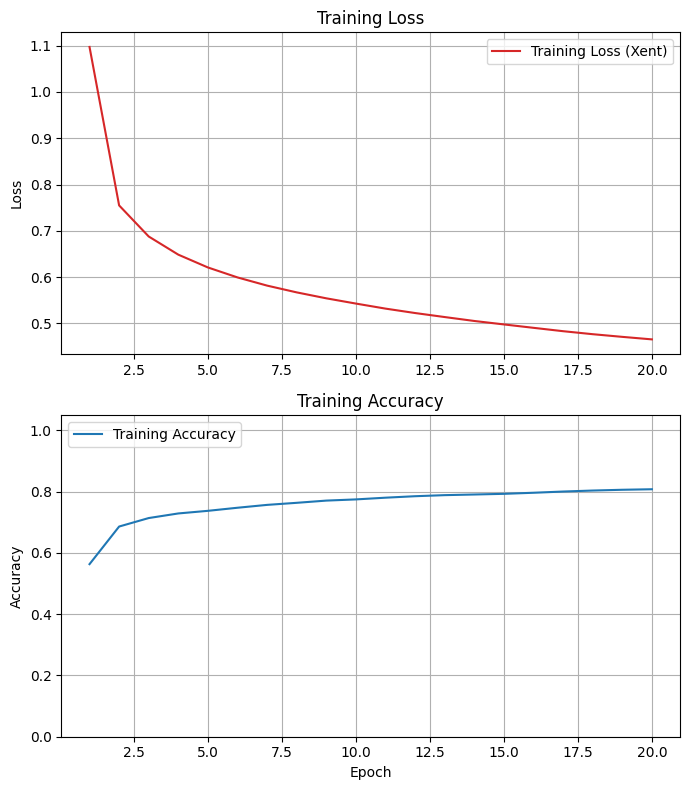

Final Training Loss:     0.4657
Final Training Accuracy: 0.8078
Final training accuracy at epoch 20 (lr=0.001): 0.8078

Training with learning_rate = 0.0005
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5288 - loss: 1.2520 - val_accuracy: 0.6393 - val_loss: 0.9189
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6565 - loss: 0.8416 - val_accuracy: 0.6766 - val_loss: 0.8133
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6822 - loss: 0.7682 - val_accuracy: 0.6880 - val_loss: 0.7589
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6962 - loss: 0.7237 - val_accuracy: 0.7043 - val_loss: 0.7199
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7112 - loss: 0.6899 - val_accuracy: 0.7111 - val_loss: 0.6906
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7205 - loss: 0.6635 - val_accuracy: 0.7215 - val_loss: 0.6677
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7291 - lo

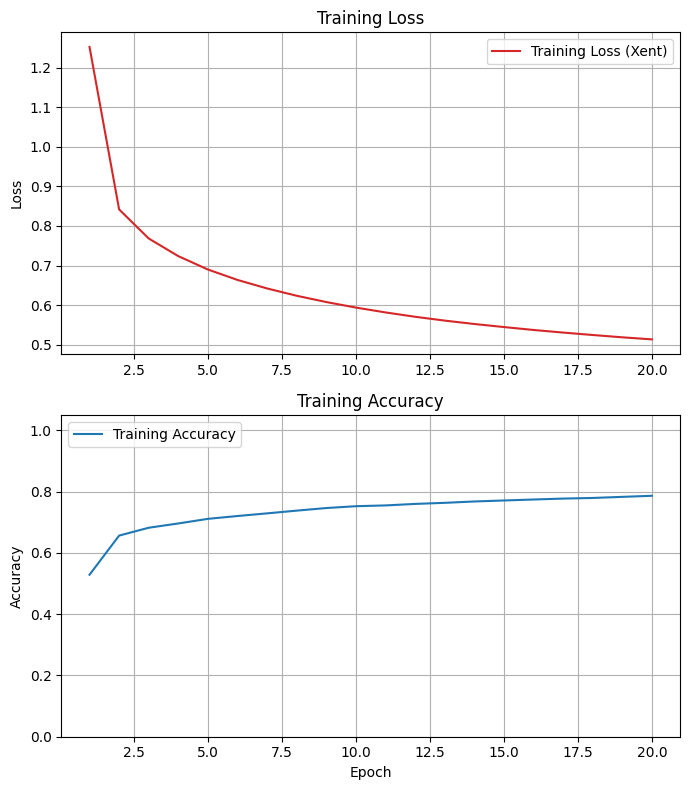

Final Training Loss:     0.5135
Final Training Accuracy: 0.7864
Final training accuracy at epoch 20 (lr=0.0005): 0.7864

Training with learning_rate = 0.0001
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3015 - loss: 1.8287 - val_accuracy: 0.4469 - val_loss: 1.6016
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5067 - loss: 1.4230 - val_accuracy: 0.5619 - val_loss: 1.2663
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5748 - loss: 1.1585 - val_accuracy: 0.5730 - val_loss: 1.0812
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5991 - loss: 1.0186 - val_accuracy: 0.6042 - val_loss: 0.9816
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6238 - loss: 0.9384 - val_accuracy: 0.6324 - val_loss: 0.9202
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6418 - loss: 0.8882 - val_accuracy: 0.6448 - val_loss: 0.8806
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6559 - l

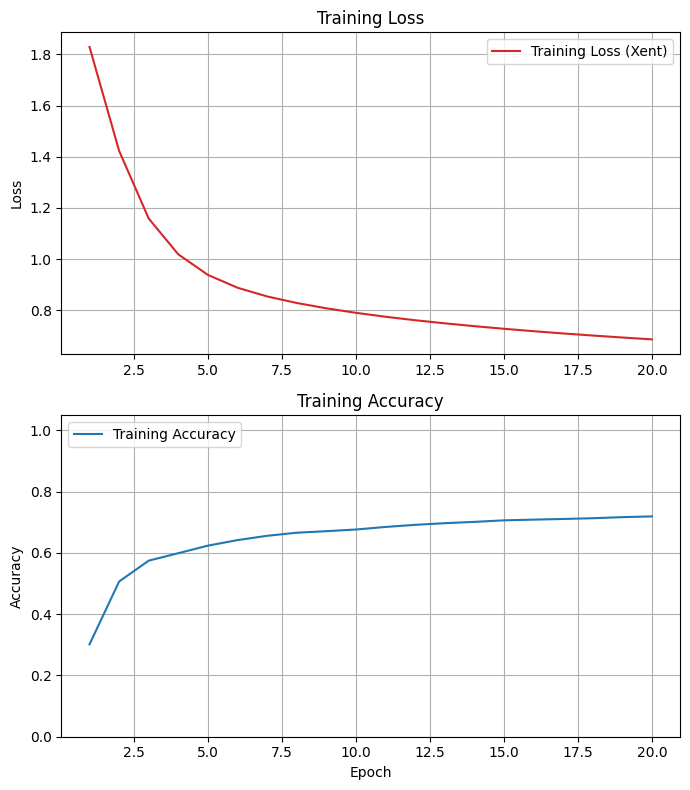

Final Training Loss:     0.6865
Final Training Accuracy: 0.7192
Final training accuracy at epoch 20 (lr=0.0001): 0.7192

Training with learning_rate = 5e-05
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2168 - loss: 1.9254 - val_accuracy: 0.3247 - val_loss: 1.7615
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4074 - loss: 1.6450 - val_accuracy: 0.4891 - val_loss: 1.5194
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5145 - loss: 1.4279 - val_accuracy: 0.5561 - val_loss: 1.3353
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5642 - loss: 1.2683 - val_accuracy: 0.5824 - val_loss: 1.2043
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5842 - loss: 1.1540 - val_accuracy: 0.5967 - val_loss: 1.1116
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5964 - loss: 1.0718 - val_accuracy: 0.6042 - val_loss: 1.0447
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6064 - lo

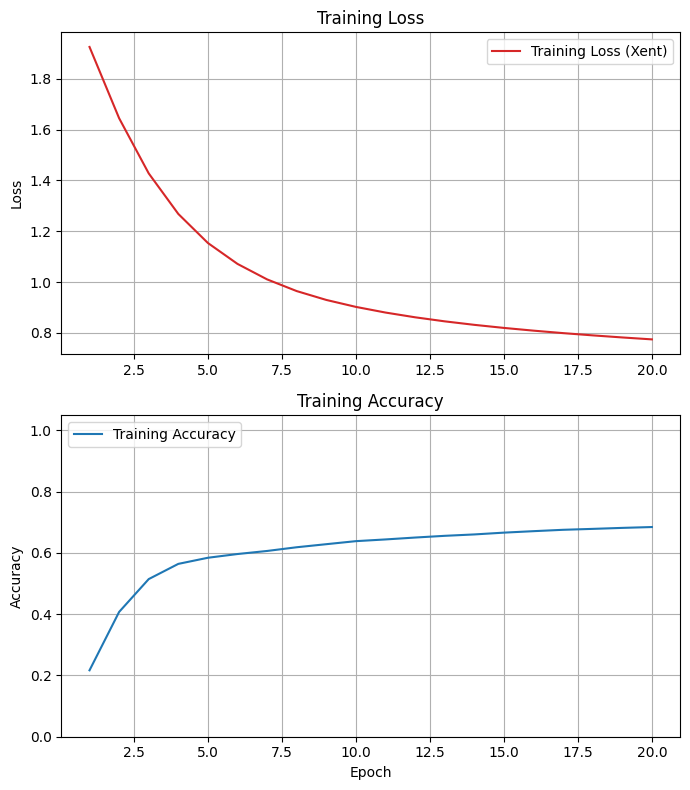

Final Training Loss:     0.7748
Final Training Accuracy: 0.6845
Final training accuracy at epoch 20 (lr=5e-05): 0.6845

Training with learning_rate = 1e-05
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1250 - loss: 1.9972 - val_accuracy: 0.1391 - val_loss: 1.9742
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1544 - loss: 1.9441 - val_accuracy: 0.1664 - val_loss: 1.9240
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1885 - loss: 1.8944 - val_accuracy: 0.2047 - val_loss: 1.8764
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2309 - loss: 1.8471 - val_accuracy: 0.2535 - val_loss: 1.8308
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2694 - loss: 1.8017 - val_accuracy: 0.2873 - val_loss: 1.7866
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3115 - loss: 1.7576 - val_accuracy: 0.3380 - val_loss: 1.7433
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3549 - los

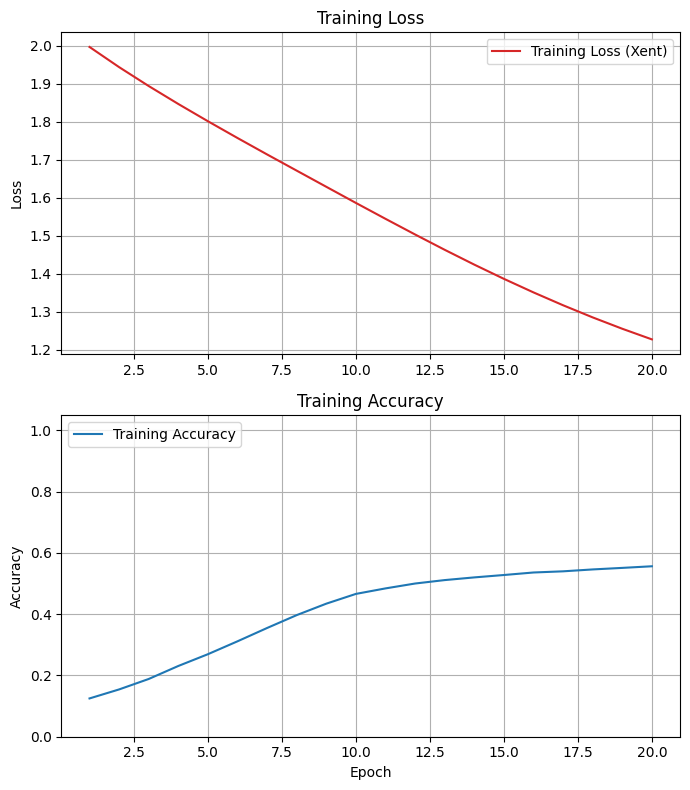

Final Training Loss:     1.2276
Final Training Accuracy: 0.5564
Final training accuracy at epoch 20 (lr=1e-05): 0.5564

Summary: Final Training Accuracy at Epoch 20
learning_rate=0.001   -> acc=0.8078
learning_rate=0.0005  -> acc=0.7864
learning_rate=0.0001  -> acc=0.7192
learning_rate=5e-05   -> acc=0.6845
learning_rate=1e-05   -> acc=0.5564

Best learning rate: 0.001
Best accuracy found (epoch 20): 0.8078


In [16]:
# Your code here
# Problem 3: Learning Rates
# Run 5 experiments with different Adam learning rates
# Here I’m keeping the model architecture and batch size fixed, and only varying the learning rate in Adam. 
# This isolates the effect of step size on optimization speed and stability. 
# I run five experiments, visualize each using plot_history, and then select the learning rate that achieves the highest training accuracy at epoch 20.

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

histories_by_lr = {}
final_train_acc_by_lr = {}

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

for lr in learning_rates:
    print("\n" + "="*70)
    print(f"Training with learning_rate = {lr}")
    print("="*70)

    # 1) Build a fresh model
    model_lr = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    # 2) Compile with current learning rate
    model_lr.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # 3) Train (same setup as baseline)
    history_lr = model_lr.fit(
        X_train_scaled,
        y_train,
        epochs=20,
        batch_size=32,          # keep batch size fixed
        validation_split=0.2,
        verbose=1
    )

    # 4) Plot training curves
    plot_history(history_lr)

    # 5) Record epoch-20 training accuracy
    final_acc = float(history_lr.history["accuracy"][-1])
    histories_by_lr[lr] = history_lr
    final_train_acc_by_lr[lr] = final_acc

    print(f"Final training accuracy at epoch 20 (lr={lr}): {final_acc:.4f}")

# Summary to identify the best learning rate
print("\n" + "="*70)
print("Summary: Final Training Accuracy at Epoch 20")
print("="*70)
for lr in learning_rates:
    print(f"learning_rate={lr:<7} -> acc={final_train_acc_by_lr[lr]:.4f}")

best_lr = max(final_train_acc_by_lr, key=final_train_acc_by_lr.get)
best_lr_acc = final_train_acc_by_lr[best_lr]

print("\nBest learning rate:", best_lr)
print("Best accuracy found (epoch 20):", f"{best_lr_acc:.4f}")


In [17]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = float(best_lr)

In [18]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [19]:
# Set a3b to the accuracy found by the best learning rate

a3b = float(best_lr_acc)

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8078


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

In [21]:
# I’m forcing CPU so TF doesn't attempt GPU init and crash in some hosted kernels.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

print("TF version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices("GPU")))

TF version: 2.20.0
Num GPUs available: 0


In [22]:
# --- Cell 1: Quick "did I rebuild everything?" sanity check ---
# Run your imports + data loading + balanced subset + Part A split/scale BEFORE this cell.
required_vars = ["X_train_scaled", "y_train"]
missing = [v for v in required_vars if v not in globals()]
assert not missing, f"Missing variables (rerun data prep cells): {missing}"

print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape, "| unique labels:", np.unique(y_train))

X_train_scaled: (15383, 54)
y_train: (15383,) | unique labels: [0 1 2 3 4 5 6]


steps_per_epoch=481, decay_steps=9620

CosineDecay run starting | initial_lr = 0.01
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6410 - loss: 0.8516 - val_accuracy: 0.7130 - val_loss: 0.6933
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6975 - loss: 0.6995 - val_accuracy: 0.7374 - val_loss: 0.6521
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7236 - loss: 0.6517 - val_accuracy: 0.7286 - val_loss: 0.6449
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7375 - loss: 0.6271 - val_accuracy: 0.7439 - val_loss: 0.6243
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7497 - loss: 0.5952 - val_accuracy: 0.7462 - val_loss: 0.6095
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7635 - loss: 0.5638 - val_accuracy: 0.7654 - val_loss: 0.5731
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7728 - loss: 0.5426 - val_accuracy: 0.7670 - val_loss: 0.5650
Epoch 8/20
385/385 ━

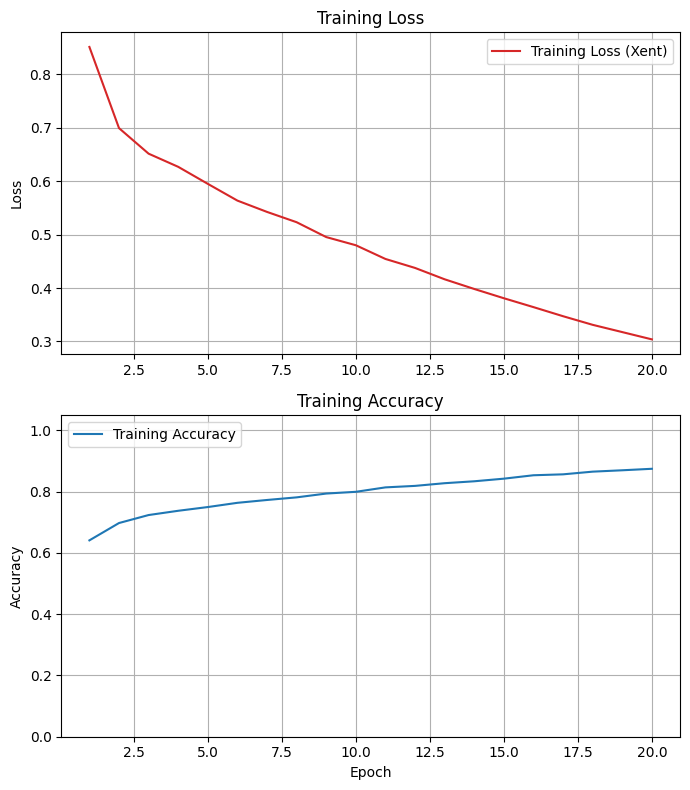

Final Training Loss:     0.3039
Final Training Accuracy: 0.8746
Final training accuracy (epoch 20) for init_lr=0.01: 0.8746

CosineDecay run starting | initial_lr = 0.005
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6430 - loss: 0.8605 - val_accuracy: 0.7160 - val_loss: 0.6910
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7118 - loss: 0.6735 - val_accuracy: 0.7364 - val_loss: 0.6344
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7382 - loss: 0.6205 - val_accuracy: 0.7540 - val_loss: 0.6026
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7541 - loss: 0.5856 - val_accuracy: 0.7657 - val_loss: 0.5766
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7666 - loss: 0.5566 - val_accuracy: 0.7774 - val_loss: 0.5501
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7781 - loss: 0.5287 - val_accuracy: 0.7901 - val_loss: 0.5312
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accurac

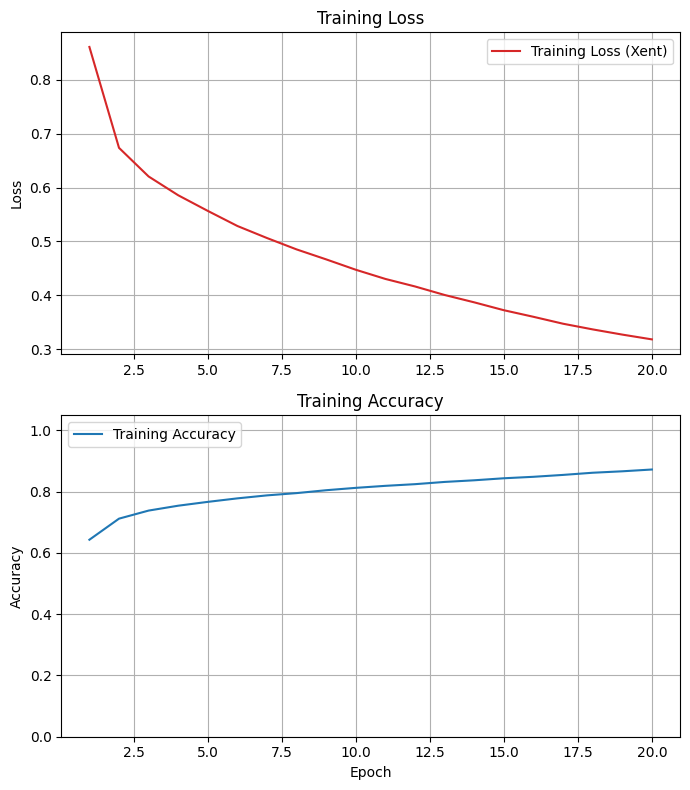

Final Training Loss:     0.3185
Final Training Accuracy: 0.8723
Final training accuracy (epoch 20) for init_lr=0.005: 0.8723

CosineDecay run starting | initial_lr = 0.001
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5804 - loss: 1.0653 - val_accuracy: 0.6575 - val_loss: 0.8255
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6846 - loss: 0.7651 - val_accuracy: 0.6945 - val_loss: 0.7345
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7102 - loss: 0.6953 - val_accuracy: 0.7199 - val_loss: 0.6790
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7270 - loss: 0.6496 - val_accuracy: 0.7322 - val_loss: 0.6456
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7404 - loss: 0.6180 - val_accuracy: 0.7449 - val_loss: 0.6218
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7497 - loss: 0.5935 - val_accuracy: 0.7491 - val_loss: 0.6057
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accura

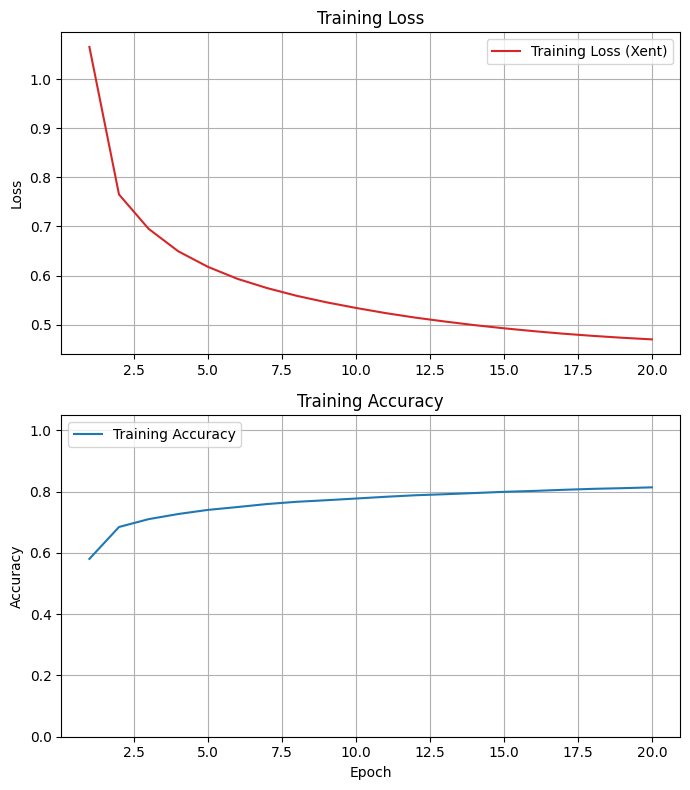

Final Training Loss:     0.4703
Final Training Accuracy: 0.8140
Final training accuracy (epoch 20) for init_lr=0.001: 0.8140

CosineDecay run starting | initial_lr = 0.0005
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5384 - loss: 1.2287 - val_accuracy: 0.6311 - val_loss: 0.9285
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6478 - loss: 0.8521 - val_accuracy: 0.6688 - val_loss: 0.8296
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6777 - loss: 0.7803 - val_accuracy: 0.6887 - val_loss: 0.7767
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6982 - loss: 0.7358 - val_accuracy: 0.7026 - val_loss: 0.7368
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7140 - loss: 0.7024 - val_accuracy: 0.7121 - val_loss: 0.7069
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7241 - loss: 0.6760 - val_accuracy: 0.7212 - val_loss: 0.6837
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accur

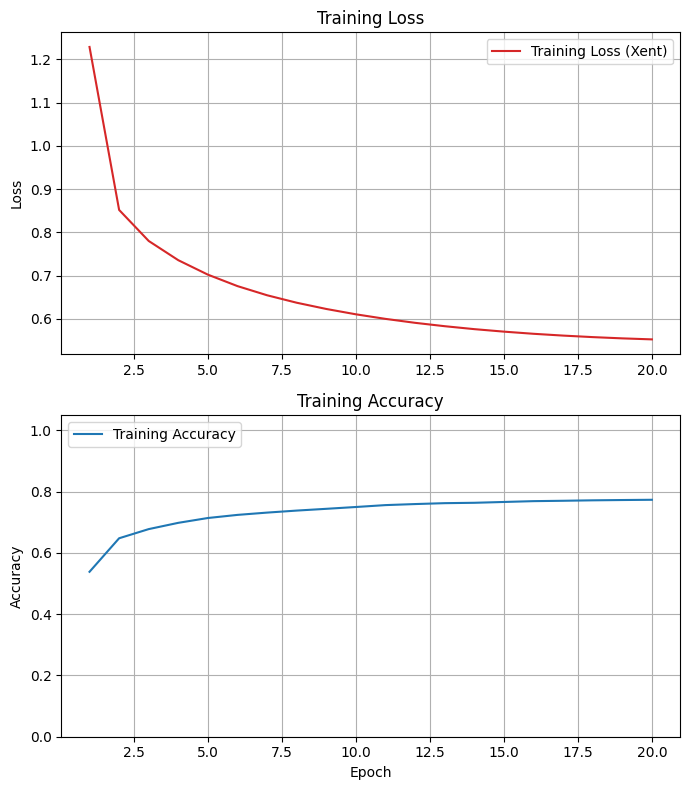

Final Training Loss:     0.5529
Final Training Accuracy: 0.7734
Final training accuracy (epoch 20) for init_lr=0.0005: 0.7734

CosineDecay run starting | initial_lr = 0.0001
Epoch 1/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3223 - loss: 1.7776 - val_accuracy: 0.4517 - val_loss: 1.5537
Epoch 2/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5278 - loss: 1.3671 - val_accuracy: 0.5713 - val_loss: 1.2034
Epoch 3/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5948 - loss: 1.0951 - val_accuracy: 0.6029 - val_loss: 1.0209
Epoch 4/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6177 - loss: 0.9659 - val_accuracy: 0.6240 - val_loss: 0.9382
Epoch 5/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6345 - loss: 0.9031 - val_accuracy: 0.6380 - val_loss: 0.8949
Epoch 6/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6477 - loss: 0.8665 - val_accuracy: 0.6513 - val_loss: 0.8672
Epoch 7/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accu

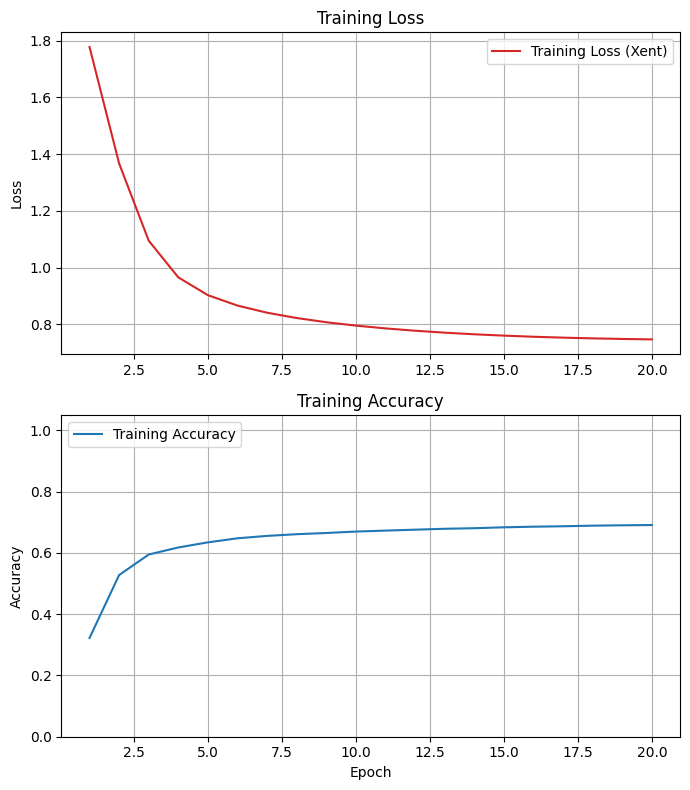

Final Training Loss:     0.7475
Final Training Accuracy: 0.6910
Final training accuracy (epoch 20) for init_lr=0.0001: 0.6910

Best initial LR (CosineDecay): 0.01
Best accuracy found: 0.8746


In [23]:
# --- Cell 2: Problem 4 (CosineDecay) but with extra safeguards ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

# If you imported plot_history earlier in your notebook, keep using that.
# This cell assumes plot_history(history) already exists.

initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]

epochs = 20
batch_size = 32

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

steps_per_epoch = int(np.ceil(len(X_train_scaled) / batch_size))
decay_steps = steps_per_epoch * epochs

histories_by_cd = {}
final_train_acc_by_cd = {}

print(f"steps_per_epoch={steps_per_epoch}, decay_steps={decay_steps}")

for init_lr in initial_lrs:
    print("\n" + "="*70)
    print(f"CosineDecay run starting | initial_lr = {init_lr}")
    print("="*70)

    # Clearing between runs helps prevent TF graph/resource buildup.
    tf.keras.backend.clear_session()
    tf.random.set_seed(random_seed)

    lr_schedule = CosineDecay(
        initial_learning_rate=init_lr,
        decay_steps=decay_steps
    )

    model_cd = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    model_cd.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_cd = model_cd.fit(
        X_train_scaled,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )

    plot_history(history_cd)

    final_acc = float(history_cd.history["accuracy"][-1])
    histories_by_cd[init_lr] = history_cd
    final_train_acc_by_cd[init_lr] = final_acc

    print(f"Final training accuracy (epoch {epochs}) for init_lr={init_lr}: {final_acc:.4f}")

best_cd_lr = max(final_train_acc_by_cd, key=final_train_acc_by_cd.get)
best_cd_acc = final_train_acc_by_cd[best_cd_lr]

print("\nBest initial LR (CosineDecay):", best_cd_lr)
print("Best accuracy found:", f"{best_cd_acc:.4f}")

In [24]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = float(best_cd_lr)

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [26]:
# Set a4b to the best accuracy found

a4b = float(best_cd_acc)

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8746


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

Epoch 1/20


3077/3077 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6377 - loss: 0.8835 - val_accuracy: 0.6961 - val_loss: 0.7388
Epoch 2/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7160 - loss: 0.6745 - val_accuracy: 0.7303 - val_loss: 0.6694
Epoch 3/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7388 - loss: 0.6174 - val_accuracy: 0.7433 - val_loss: 0.6398
Epoch 4/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7566 - loss: 0.5817 - val_accuracy: 0.7514 - val_loss: 0.6096
Epoch 5/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7682 - loss: 0.5557 - val_accuracy: 0.7641 - val_loss: 0.5885
Epoch 6/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7776 - loss: 0.5355 - val_accuracy: 0.7683 - val_loss: 0.5759
Epoch 7/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7860 - loss: 0.5186 - val_accuracy: 0.7732 - val_loss: 0.5593
Epoch 8/20
3077/3077 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7940 - loss: 0.5032 - val_accurac

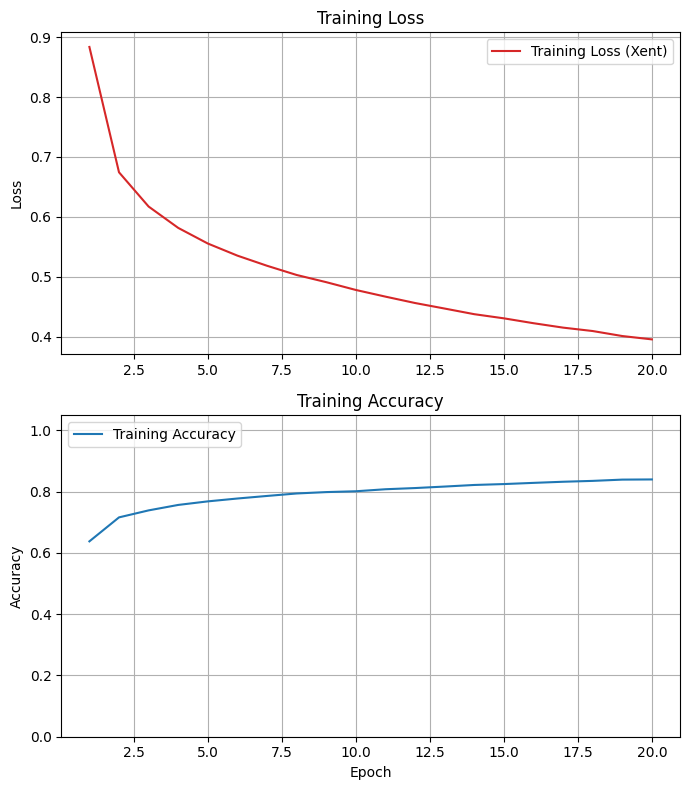

Final Training Loss:     0.3958
Final Training Accuracy: 0.8398
Final Train Accuracy: 0.8401 | Train Loss: 0.4080
Final Test  Accuracy: 0.8073 | Test  Loss: 0.5175


In [28]:
# Problem 5: Train the best model and evaluate on the test set

# Best hyperparameters from earlier experiments
best_batch_size = 4
best_learning_rate = 1e-3
epochs = 20

n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))

# Build the model (same architecture as before)
best_model = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(n_classes, activation="softmax")
])

# Compile with best constant learning rate
best_model.compile(
    optimizer=Adam(learning_rate=best_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
best_history = best_model.fit(
    X_train_scaled,
    y_train,
    epochs=epochs,
    batch_size=best_batch_size,
    validation_split=0.2,
    verbose=1
)

# Plot training curves
plot_history(best_history)

# Evaluate on training and test sets
train_loss, train_acc = best_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc = best_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Final Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Final Test  Accuracy: {test_acc:.4f} | Test  Loss: {test_loss:.4f}")

In [29]:
# Set a5a to the best training accuracy found by your best model

a5a = float(best_history.history["accuracy"][-1])

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8398


In [31]:
# Set a5b to the test accuracy found by your best model

a5b = float(test_acc)

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8073


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

   If I increase the balanced subset size, I would expect training time to increase roughly linearly, since there are more samples per epoch and more gradient updates overall. I’d also expect the best batch size to increase modestly, because with more data the gradient estimate becomes more stable and larger batches can be used without losing as much stochastic benefit. Finally, I’d expect the best learning rate to increase slightly or remain similar, since larger datasets can often tolerate (and sometimes benefit from) slightly larger learning rates due to smoother average gradients.

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

   With epochs fixed, smaller batches often generalize better on tabular data because the added gradient noise acts as implicit regularization, helping the optimizer avoid sharp minima. In this assignment, smaller batch sizes clearly led to better accuracy within a fixed training budget. If I were forced to use a large batch, I would compensate by reducing the learning rate, potentially adding a learning-rate schedule (e.g., cosine decay), and possibly training for more epochs to recover lost optimization dynamics.

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

    If I doubled the number of epochs while keeping the learning rate fixed, I would expect training loss to continue decreasing and training accuracy to increase, at least initially. Test accuracy would likely improve at first, but then plateau or slightly degrade if overfitting sets in. Given how close train and test accuracy already were, additional epochs would probably produce diminishing returns unless paired with regularization or learning-rate decay.

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

   While it’s tempting to think epochs and learning rate are inversely interchangeable, our experiments suggest this is only partially true. Very small learning rates did not simply “catch up” within 20 epochs, even though they were more stable. In contrast, a larger learning rate (1e-3) reached much better performance quickly. This shows that learning rate controls where the optimizer can go, not just how fast, and that too-small learning rates can prevent the model from reaching good solutions within a reasonable epoch budget.

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


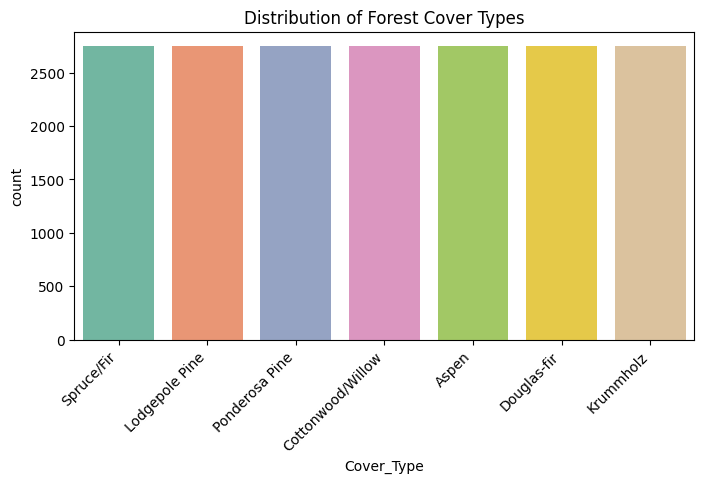

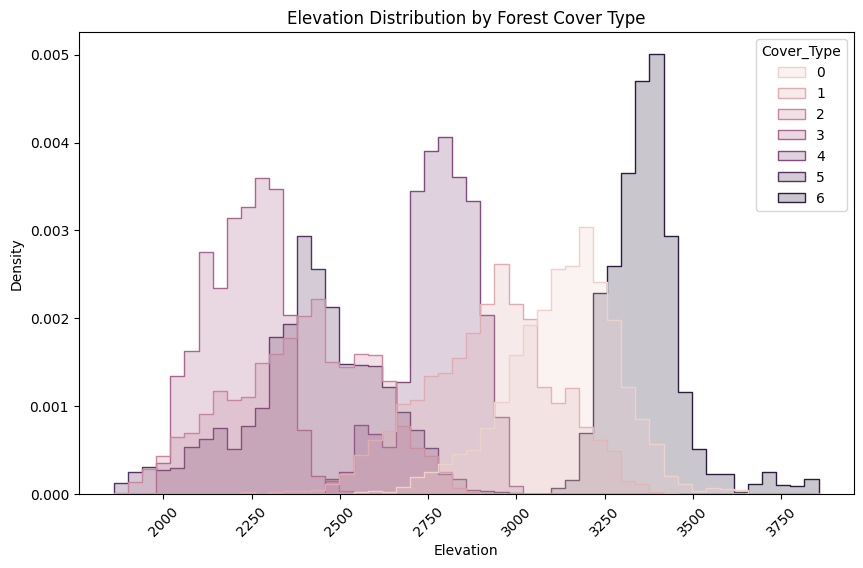

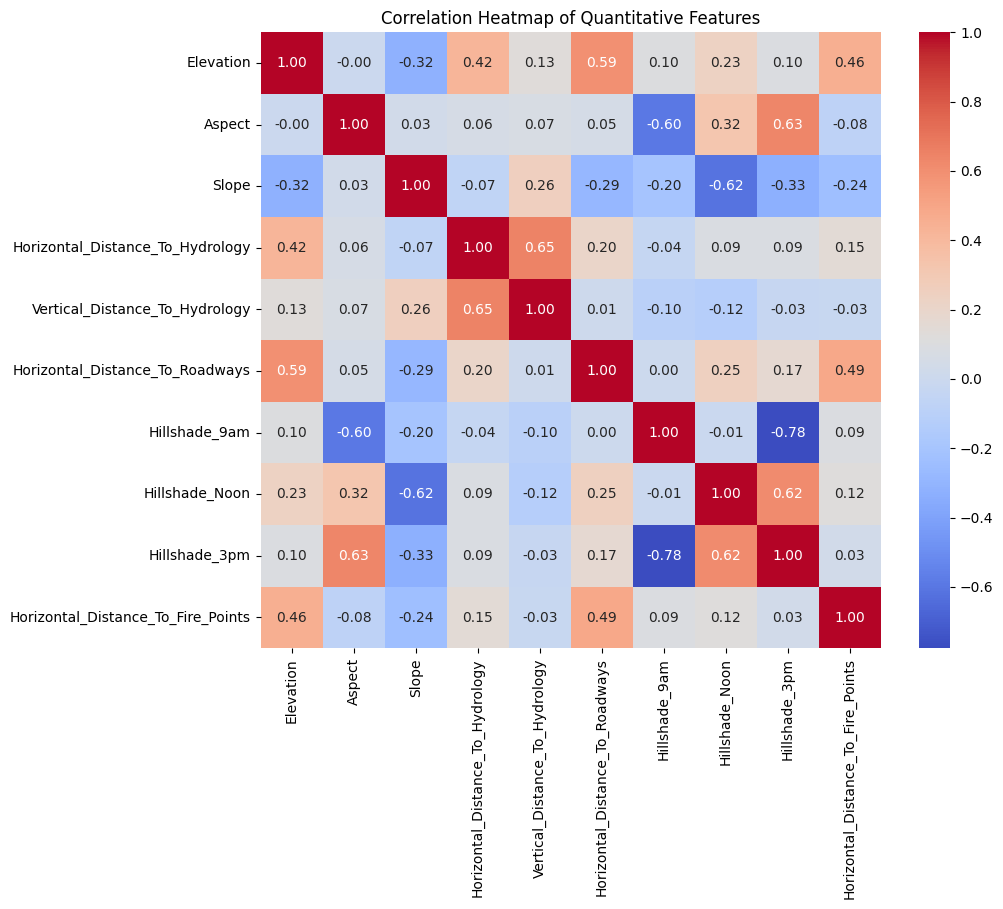

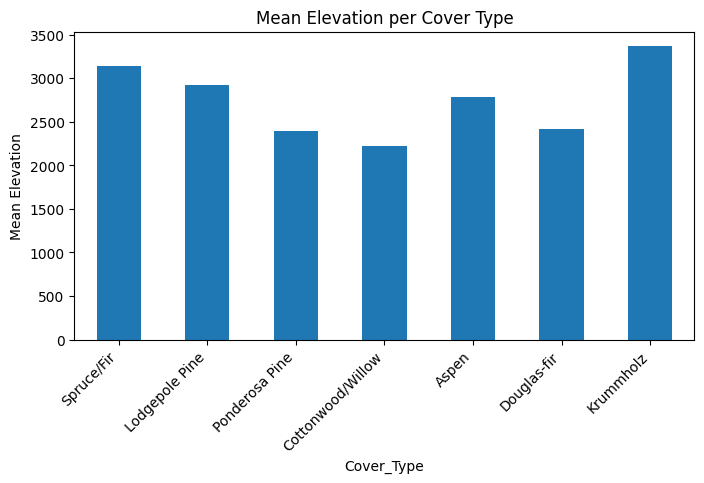

In [33]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
